# Library

In [1]:
import sys
sys.path.append("/project/assistant")

%load_ext autoreload
%autoreload 2

import os

# huggingface downloads: quiet text logs, no widget progress bars
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["HF_HUB_VERBOSITY"] = "error"

import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from elasticsearch import Elasticsearch
from openai import OpenAI

from cleaner import NoteCleaner
from embeddings import SentenceTransformerEmbeddings
from ingest import VaultLoader, SlidingWindowSplitter, ElasticsearchIndexer
from judge import LLMJudge
from rag import ObsidianRAG
from rewriter import QueryRewriter, RewriteFusedSearch
from search import VaultSearcher, ElasticsearchRetriever

# Course Criteria Evaluation

The demo vault documents the project itself, allowing a reviewer to question the assistant about every evaluation criterion and verify each answer against the underlying sources. This notebook simulates that evaluation with 50 questions: five per criterion, four direct and one harder, each linked to the demo note that contains the expected answer. The dataset is committed at `data/claude_course_criteria_questions.json`.

The notebook is fully self-contained. It builds a separate temporary index from the demo vault, leaving the application's current index untouched, then answers every question using the same RAG chain used in production. Each response is evaluated with the same LLM judge used in the generation benchmark, and the results are analyzed per evaluation criterion.

Success here means more than good average retrieval or generation metrics: the system must be able to explain itself reliably across every one of the course's evaluation criteria.


In [2]:
INDEX = "demo_criteria"

es = Elasticsearch(os.getenv("ELASTIC_HOST", "http://elasticsearch:9200"))
embeddings = SentenceTransformerEmbeddings(os.getenv("EMBED_MODEL", "all-MiniLM-L6-v2"))

docs = VaultLoader("/project/demo_vault", NoteCleaner()).load()
chunks = SlidingWindowSplitter(chunk_size=2000, chunk_overlap=1000).split_documents(docs)
print(f"{len(docs)} notes -> {len(chunks)} chunks")

indexer = ElasticsearchIndexer(es, embeddings, index=INDEX, add_context_header=True)
indexer.create_index(recreate=True)
indexer.index_documents(chunks)
es.indices.refresh(index=INDEX)

searcher = VaultSearcher(es, embeddings, INDEX)

# the same retrieval production runs: the fused rewrite is the app default
gpt = OpenAI()
rewriter = QueryRewriter(gpt, model="gpt-5.4-mini")
fused = RewriteFusedSearch(searcher, rewriter)
retriever = ElasticsearchRetriever(search_fn=fused.search, num_results=10)

rag = ObsidianRAG(retriever, gpt, model="gpt-5.4-mini")
judge_llm = LLMJudge(gpt, model="gpt-5.4-mini")

66 notes -> 348 chunks


In [3]:
criteria = pd.read_json("/project/data/claude_course_criteria_questions.json")
print(len(criteria), "questions |", criteria.criterion.nunique(), "criteria |",
      dict(criteria.difficulty.value_counts()))

for q in criteria.sample(3, random_state=1).itertuples():
    print(f"[{q.criterion} / {q.difficulty}] {q.question}")
    print(f"   -> {q.path}")

50 questions | 10 criteria | {'easy': np.int64(40), 'hard': np.int64(10)}
[ingestion_pipeline / easy] How do I reindex after adding a new note?
   -> project/03-ingestion-pipeline.md
[containerization / easy] How is the project containerized?
   -> project/02-architecture.md
[reproducibility / easy] What do I need to run this project from a fresh clone?
   -> project/09-running-it.md


In [4]:
print("Easy questions:")
display(list(criteria[criteria['difficulty'] == 'easy']['question'][:10]))

print("\n Hard questions:")
display(list(criteria[criteria['difficulty'] == 'hard']['question'][:10]))

Easy questions:


['What problem does the obsidian assistant solve?',
 'What is the obsidian assistant and what does it do with my notes?',
 'Can the assistant modify or delete my notes?',
 'Which course is this the final project of?',
 'What happens between typing a question and seeing the answer?',
 'How does the assistant decide which notes to send to the model?',
 'How many chunks does the retriever feed the model, and why that number?',
 'How does the prompt show the model where each excerpt came from?',
 'Which retrieval method does this project use by default, and why?',
 'What hit rate does hybrid search achieve on the ground truth?']


 Hard questions:


['If I already use a chat model every day, what does this project give me that a plain chat cannot?',
 'Why does the assistant sometimes answer that it could not find something in the vault?',
 'Why do the hard questions of the ground truth fail more often than the easy ones?',
 'What is the retrieval ceiling, and which model sits exactly on it?',
 'After I vote on an answer, where does that vote end up and who reads it?',
 'Why did batching the embedding calls make ingestion an order of magnitude faster?',
 'Why can a failure of the judge never block an answer?',
 'Why does editing code not require rebuilding the image, while changing the env file requires recreating the container?',
 'Why does the retrieval evaluation give slightly different numbers over the full demo vault than the ones reported?',
 'Why does reranking barely change the hit rate while improving MRR a lot?']

The full evaluation answers and judges all 50 rubric questions, taking about four minutes and only a few cents in API cost. Results are cached after the first run in `data/course_criteria_evaluation.csv`; delete the file to execute the benchmark again from scratch.

Each question also records a retrieval hit flag indicating whether the expected demo note appeared among the 10 retrieved chunks. This makes every failure traceable to either retrieval or generation, using the same decomposition adopted in the generation evaluation.


In [5]:
RESULTS_PATH = Path("/project/data/course_criteria_evaluation.csv")

if RESULTS_PATH.exists():
    results = pd.read_csv(RESULTS_PATH)
    print(f"loaded cached results: {len(results)} rows")
else:
    rows = []
    for q in tqdm(criteria.itertuples(), total=len(criteria)):
        started = time.time()
        out = rag.invoke(q.question)
        elapsed = time.time() - started
        verdict = judge_llm.judge(q.question, out["answer"])
        retrieved = [d.metadata["source"] for d in out["source_documents"]]
        rows.append({
            "criterion": q.criterion,
            "difficulty": q.difficulty,
            "question": q.question,
            "expected": q.path,
            "hit": q.path in retrieved,
            "relevance": verdict.relevance,
            "reasoning": verdict.reasoning,
            "answer": out["answer"],
            "response_time": elapsed,
        })
    results = pd.DataFrame(rows)
    results.to_csv(RESULTS_PATH, index=False)
    print(f"saved {len(results)} rows to {RESULTS_PATH}")

100%|██████████| 50/50 [03:59<00:00,  4.79s/it]

saved 50 rows to /project/data/course_criteria_evaluation.csv


In [6]:
summary = results.groupby("criterion").agg(
    relevant=("relevance", lambda s: (s == "RELEVANT").mean()),
    partly=("relevance", lambda s: (s == "PARTLY_RELEVANT").mean()),
    non_relevant=("relevance", lambda s: (s == "NON_RELEVANT").mean()),
    retrieval_hit=("hit", "mean"),
).round(2).sort_values("relevant", ascending=False)

overall = (results.relevance == "RELEVANT").mean()
print(f"overall RELEVANT: {overall:.0%}")
summary

overall RELEVANT: 94%


,relevant,partly,non_relevant,retrieval_hit
criterion,,,,
best_practices,1.0,0.0,0.0,1.0
containerization,1.0,0.0,0.0,1.0
ingestion_pipeline,1.0,0.0,0.0,1.0
llm_evaluation,1.0,0.0,0.0,1.0
monitoring,1.0,0.0,0.0,0.8
retrieval_flow,1.0,0.0,0.0,1.0
retrieval_evaluation,1.0,0.0,0.0,1.0
interface,0.8,0.2,0.0,0.6
reproducibility,0.8,0.0,0.2,0.8


The chart shows the verdict composition for each rubric criterion using the same visual language as the other evaluation notebooks: blue represents the share of `RELEVANT` answers, gray the `PARTLY_RELEVANT` responses, and orange the `NON_RELEVANT` failures.


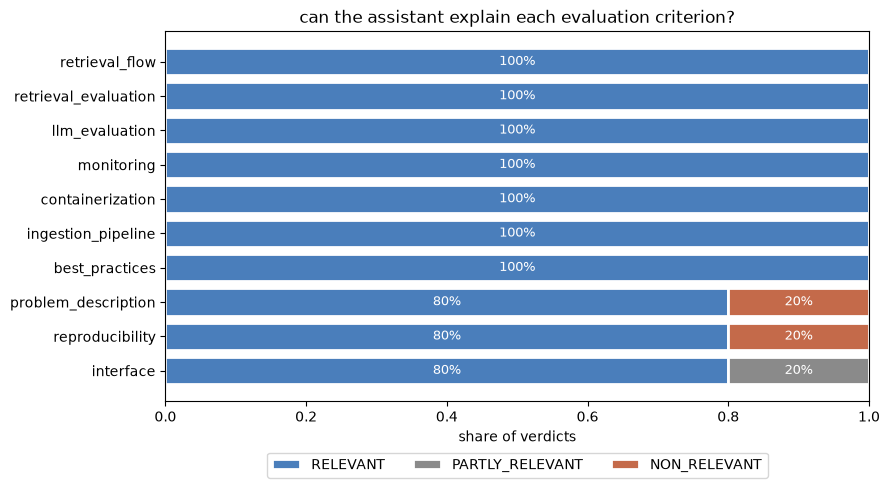

In [7]:
order = ["RELEVANT", "PARTLY_RELEVANT", "NON_RELEVANT"]
colors = {"RELEVANT": "#4a7ebb", "PARTLY_RELEVANT": "#8a8a8a",
          "NON_RELEVANT": "#c46a4a"}

share = (results.groupby("criterion")["relevance"].value_counts(normalize=True)
         .unstack().reindex(columns=order).fillna(0)
         .sort_values("RELEVANT"))

fig, ax = plt.subplots(figsize=(9, 5))
left = np.zeros(len(share))
for verdict in order:
    vals = share[verdict].values
    ax.barh(share.index, vals, left=left, color=colors[verdict],
            label=verdict, edgecolor="white", linewidth=2)
    for y, (start, v) in enumerate(zip(left, vals)):
        if v > 0.06:
            ax.text(start + v / 2, y, f"{v:.0%}", ha="center",
                    va="center", color="white", fontsize=9)
    left += vals
ax.set_xlim(0, 1)
ax.set_xlabel("share of verdicts")
ax.set_title("can the assistant explain each evaluation criterion?")
ax.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.12))
plt.tight_layout()
plt.show()

In [8]:
# the failures, with the retrieval side attached: hit=False points at
# retrieval, hit=True at the answer or the note content itself
failures = results[results.relevance != "RELEVANT"]
failures[["criterion", "difficulty", "question", "hit", "relevance", "reasoning"]]

,criterion,difficulty,question,hit,relevance,reasoning
3,problem_description,easy,Which course is this the final project of?,False,NON_RELEVANT,The question asks for a specific factual answe...
22,interface,easy,What information appears under each answer bes...,True,PARTLY_RELEVANT,The generated answer is relevant to the questi...
41,reproducibility,easy,How do I point the assistant at my own notes?,False,NON_RELEVANT,The question asks how to point the assistant a...


In [9]:
print("Easy questions:")
display(list(failures[failures['difficulty'] == 'easy']['question'][:10]))

print("\n Hard questions:")
display(list(failures[failures['difficulty'] == 'hard']['question'][:10]))

Easy questions:


['Which course is this the final project of?',
 'What information appears under each answer besides the text?',
 'How do I point the assistant at my own notes?']


 Hard questions:


[]

This run evaluates the full production pipeline: fused query rewriting followed by retrieval, using the updated demo vault. The system reaches **94% `RELEVANT`**, the best result recorded so far, with seven of the ten rubric criteria scoring perfectly. More importantly, all ten hard questions are answered correctly, including the mechanism-focused ones. This is the first run in which the hard subset is fully solved.

The three remaining failures are all easy questions and each can be traced to a specific stage. Two are retrieval misses (`hit=False`): the recurring question about which course the project belongs to, and the phrasing asking how to point the assistant at the user's own notes. The latter is especially informative: query rewriting now handles the more common “vault” wording, but this exact formulation still falls outside the candidate set. The third failure is on the generation side (`hit=True`, `PARTLY_RELEVANT`): the correct context was retrieved, but the final answer was incomplete.

The aggregate score should still be interpreted with some caution. With only five questions per criterion, each individual question contributes 20 percentage points to that criterion, so small run-to-run variations are expected. The more stable result is the failure pattern: the hard questions no longer fail, and the remaining errors are few, explicit, and attributable to the two already known bottlenecks, retrieval misses and generation loss.
